In [21]:
## importing libraries
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## libraries for preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split




In [6]:
## load the data
df = pd.read_csv(r'D:\SML_Project\artifacts\train_data.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,master's degree,standard,none,62,70,75
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83
2,female,group D,some college,free/reduced,none,79,89,86
3,male,group C,master's degree,free/reduced,none,61,67,66
4,male,group E,high school,standard,none,73,64,57


In [7]:
df["overall_score"] = df["math score"] + df["reading score"] + df["writing score"]

In [8]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,female,group D,master's degree,standard,none,62,70,75,207
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83,232
2,female,group D,some college,free/reduced,none,79,89,86,254
3,male,group C,master's degree,free/reduced,none,61,67,66,194
4,male,group E,high school,standard,none,73,64,57,194


In [9]:
df.gender.value_counts()

gender
female    421
male      379
Name: count, dtype: int64

In [11]:
df["race/ethnicity"].value_counts()

race/ethnicity
group C    260
group D    202
group B    153
group E    116
group A     69
Name: count, dtype: int64

In [16]:
## one hot
cat_one = ["gender","lunch","test preparation course"]
ohe = OneHotEncoder(drop="first")
for i in cat_one:
    df[i] = ohe.fit_transform(df[[i]]).toarray()

In [17]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,0.0,group D,master's degree,1.0,1.0,62,70,75,207
1,0.0,group C,bachelor's degree,0.0,0.0,66,83,83,232
2,0.0,group D,some college,0.0,1.0,79,89,86,254
3,1.0,group C,master's degree,0.0,1.0,61,67,66,194
4,1.0,group E,high school,1.0,1.0,73,64,57,194


In [18]:
## label encoding helps to encode ordinal categorical variables into numerical values. 

cat_label = ["race/ethnicity","parental level of education"]
enco = LabelEncoder()
for i in cat_label:
    df[i] = enco.fit_transform(df[i])

In [19]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,0.0,3,3,1.0,1.0,62,70,75,207
1,0.0,2,1,0.0,0.0,66,83,83,232
2,0.0,3,4,0.0,1.0,79,89,86,254
3,1.0,2,3,0.0,1.0,61,67,66,194
4,1.0,4,2,1.0,1.0,73,64,57,194


In [20]:
## separating features and target
x = df.drop(columns=["overall_score"])
y = df["overall_score"]

In [22]:
## normalization
normal = MinMaxScaler()
x = normal.fit_transform(x)

In [23]:
## train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
## model building
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
model = LinearRegression()
model.fit(x_train,y_train)
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)
print("R2 score for train data:",r2_score(y_train,y_pred_train))
print("R2 score for test data:",r2_score(y_test,y_pred_test))
print("Mean squared error for train data:",mean_squared_error(y_train,y_pred_train))
print("Mean squared error for test data:",mean_squared_error(y_test,y_pred_test))


R2 score for train data: 1.0
R2 score for test data: 1.0
Mean squared error for train data: 5.4292562940930914e-27
Mean squared error for test data: 5.918350055330119e-27


In [27]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
model = DecisionTreeRegressor()
model.fit(x_train, y_train)
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)
print("R2 score for train data:",r2_score(y_train,y_pred_train))
print("R2 score for test data:",r2_score(y_test,y_pred_test))
print("Mean squared error for train data:",mean_squared_error(y_train,y_pred_train))
print("Mean squared error for test data:",mean_squared_error(y_test,y_pred_test))


R2 score for train data: 1.0
R2 score for test data: 0.9864523855983329
Mean squared error for train data: 0.0
Mean squared error for test data: 24.73125


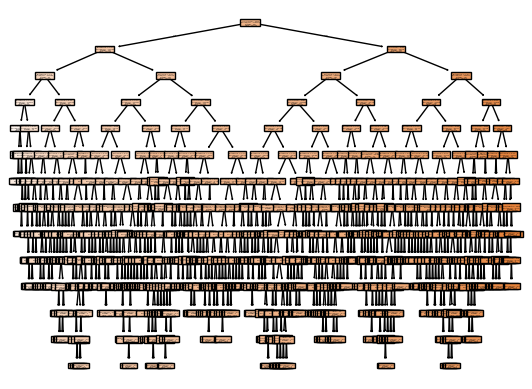

In [29]:
plot_tree(model, feature_names=df.drop(columns=["overall_score"]).columns, filled=True)
plt.show()

In [ ]:
## hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {"ccp_alpha":[0.1, 1, 10, 100],
                    "min_samples_split":[2,5,10],
                        "min_samples_leaf":[1,2,4],
                        "max_depth":[None,10,20,30]}
dtree = DecisionTreeRegressor()
grid_search = GridSearchCV(estimator=dtree, param_grid=param_grid, cv=5)
grid_search.fit(x_train,y_train)
print("Best parameters:", grid_search.best_params_)
best_dtree = grid_search.best_estimator_
y_pred_train = best_dtree.predict(x_train)
y_pred_test = best_dtree.predict(x_test)
print("R2 score for train data:",r2_score(y_train,y_pred_train))
print("R2 score for test data:",r2_score(y_test,y_pred_test))
print("Mean squared error for train data:",mean_squared_error(y_train,y_pred_train))
print("Mean squared error for test data:",mean_squared_error(y_test,y_pred_test))

Best parameters: {'ccp_alpha': 0.1, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 score for train data: 0.9966950560952091
R2 score for test data: 0.9864414493826319
Mean squared error for train data: 5.897597125097125
Mean squared error for test data: 24.75121412626892


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {"ccp_alpha": [0.1, 1, 10, 100],
              "min_samples_split": [2, 5, 10],
              "min_samples_leaf": [1, 2, 4],
              "max_depth": [None, 10, 20, 30]}
dtree = DecisionTreeRegressor()
random_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_dist, n_iter=10, cv=5, random_state=42)
random_search.fit(x_train, y_train)
print("Best parameters:", random_search.best_params_) 
best_model = random_search.best_estimator_
y_pred_train = best_model.predict(x_train)
y_pred_test = best_model.predict(x_test)
print("R2 score for train data:",r2_score(y_train,y_pred_train))
print("R2 score for test data:",r2_score(y_test,y_pred_test))
print("Mean squared error for train data:",mean_squared_error(y_train,y_pred_train))
print("Mean squared error for test data:",mean_squared_error(y_test,y_pred_test))


Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'ccp_alpha': 0.1}
R2 score for train data: 0.9966950560952091
R2 score for test data: 0.9835736558519932
Mean squared error for train data: 5.897597125097125
Mean squared error for test data: 29.98638813195074


In [43]:
## Best parameters: {'ccp_alpha': 0.1, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

dtree = DecisionTreeRegressor(ccp_alpha=0.1, max_depth=10, min_samples_leaf=1, min_samples_split=2)
dtree.fit(x_train, y_train)
y_pred_train = dtree.predict(x_train)
y_pred_test = dtree.predict(x_test)
print("R2 score for train data:",r2_score(y_train,y_pred_train))
print("R2 score for test data:",r2_score(y_test,y_pred_test))
print("Mean squared error for train data:",mean_squared_error(y_train,y_pred_train))
print("Mean squared error for test data:",mean_squared_error(y_test,y_pred_test))

R2 score for train data: 0.9966840112910937
R2 score for test data: 0.984369498871131
Mean squared error for train data: 5.917306326486014
Mean squared error for test data: 28.533572006284352
